Dataset Preview:
   CustomerID ProductID  Quantity      Price   TransactionDate PaymentMethod  \
0      109318         C         7  80.079844  12/26/2023 12:32          Cash   
1      993229         C         4  75.195229     8/5/2023 0:00          Cash   
2      579675         A         8  31.528816   3/11/2024 18:51          Cash   
3      799826         D         5  98.880218  10/27/2023 22:00        PayPal   
4      121413         A         7  93.188512  12/22/2023 11:38          Cash   

                                       StoreLocation ProductCategory  \
0            176 Andrew Cliffs\nBaileyfort, HI 93354           Books   
1  11635 William Well Suite 809\nEast Kara, MT 19483      Home Decor   
2  910 Mendez Ville Suite 909\nPort Lauraland, MO...           Books   
3  87522 Sharon Corners Suite 500\nLake Tammy, MO...           Books   
4   0070 Michelle Island Suite 143\nHoland, VA 80142     Electronics   

   DiscountApplied(%)  TotalAmount  
0           18.677100   455.8627

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Sample Transactions:
[['A'], ['B'], ['C'], ['D'], ['B']]

Encoded Basket Data:
       A      B      C      D
0   True  False  False  False
1  False   True  False  False
2  False  False   True  False
3  False  False  False   True
4  False   True  False  False

Frequent Itemsets:
   support itemsets
0  0.24665      (A)
1  0.24950      (B)
2  0.25175      (C)
3  0.25210      (D)

Association Rules:
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []

Top Rules:
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []
 
 


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


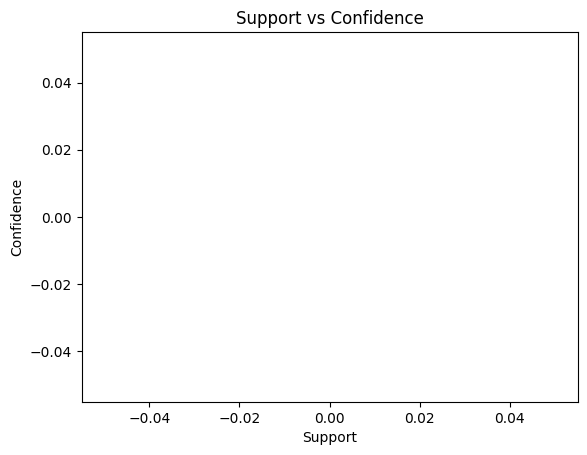

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


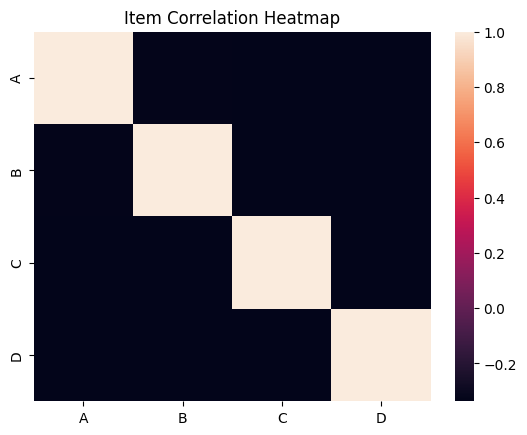

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [1]:
# ===============================
# MARKET BASKET ANALYSIS (COLAB READY - WARNINGS IGNORED)
# ===============================

# Step 0: Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Step 2: Upload Dataset
df = pd.read_csv("Retail_Transaction_Dataset.csv")

print("Dataset Preview:")
print(df.head())

# Step 3: Reduce Dataset Size (for speed)
df = df.head(20000)

# Step 4: Data Preprocessing
transactions_df = df.groupby(['CustomerID', 'TransactionDate'])['ProductID'].apply(list)
transactions = transactions_df.tolist()

print("\nSample Transactions:")
print(transactions[:5])

# Step 5: Transaction Encoding
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_array, columns=te.columns_)

print("\nEncoded Basket Data:")
print(basket.head())

# Step 6: Remove Rare Items (speed optimization)
item_counts = basket.sum()
basket = basket.loc[:, item_counts > 50]

# Step 7: Apply FP-Growth (faster than Apriori)
frequent_itemsets = fpgrowth(basket, min_support=0.05, use_colnames=True)

print("\nFrequent Itemsets:")
print(frequent_itemsets.head())

# Step 8: Generate Association Rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)

print("\nAssociation Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

# Step 9: Sort Rules
rules_sorted = rules.sort_values(by='lift', ascending=False)

print("\nTop Rules:")
print(rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

# Step 10: Visualization (Support vs Confidence)
print(" ")
print(" ")
plt.figure()
plt.scatter(rules['support'], rules['confidence'])
plt.title("Support vs Confidence")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.show()

# Step 11: Heatmap
print(" ")
print(" ")
plt.figure()
sns.heatmap(basket.corr(), annot=False)
plt.title("Item Correlation Heatmap")
plt.show()

# ===============================
# END
# ===============================

# Notes:
# - Warnings are suppressed for cleaner output
# - FP-Growth is used for better performance
# - Adjust min_support and thresholds based on dataset size
